## Import Library
Mengimpor semua library yang dibutuhkan: OpenCV untuk pengolahan citra, GLCM dari skimage untuk ekstraksi fitur tekstur, serta scikit-learn untuk split data, normalisasi, dan model klasifikasi (Random Forest, SVM, KNN).

In [1]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

## Load Dataset
Membaca seluruh gambar dari folder `dataset/` (tiap subfolder = label kelas). Setiap gambar diubah ke grayscale dan diresize ke 256x256, lalu disimpan ke array `data` beserta label dan nama filenya.

In [2]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

## Fungsi Baseline
Fungsi awal untuk grayscale + resize ke 128x128. Variabel `dataMedianEqual` di sini akan ditimpa oleh hasil cell median+equalisasi (cell 7), sehingga cell ini sebenarnya tidak berdampak ke hasil akhir.

In [3]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataMedianEqual = [baseline(img) for img in data]

## Pemilihan Sampel untuk Visualisasi
Mengambil 2 gambar dari masing-masing label dari datasetnya yaitu gambar scan otak normal dan versi tumor

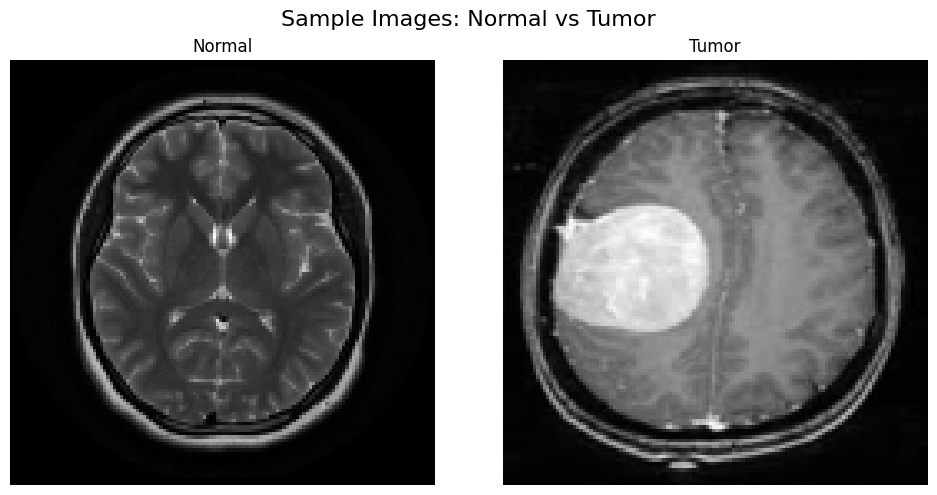

In [4]:
# ambil index berdasarkan label
normal_indx = [i for i, l in enumerate(labels) if l.lower() == "normal"]
tumor_indx = [i for i, l in enumerate(labels) if l.lower() == "tumor"]

# ambil hanya 1 sample dari masing-masing label
normal_indx = normal_indx[:1]
tumor_indx = tumor_indx[:1]

# gabungkan kedua label untuk ditampilkan bersama
all_idxs = normal_indx + tumor_indx
all_labels = ["Normal"] * len(normal_indx) + ["Tumor"] * len(tumor_indx)

def show_sample_images(idxs, labels, title):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1 baris, 2 kolom
    fig.suptitle(title, fontsize=16)
    
    for i in range(len(idxs)):
        axs[i].imshow(dataMedianEqual[idxs[i]], cmap='gray')
        axs[i].set_title(labels[i])
        axs[i].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

# tampilkan
show_sample_images(all_idxs, all_labels, "Sample Images: Normal vs Tumor")

## Fungsi Filter Citra (Mean, Median, dll)
Implementasi filter spasial manual menggunakan sliding window dengan edge padding. Mode `'median'` mengambil nilai tengah dari piksel-piksel dalam window (setelah diurutkan) untuk mengurangi noise tanpa mengaburkan tepi terlalu banyak, cocok untuk menghilangkan noise impuls (salt-and-pepper).

In [5]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)

                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = filter(foto_karim, 3, 'mean')

## Equalisasi Histogram
Fungsi `ekualisasi_histogram` ini melakukan **peregangan kontras** pada citra secara manual tanpa menggunakan library. Prosesnya dimulai dengan menghitung histogram frekuensi setiap nilai intensitas (0-255) dari citra input menggunakan perulangan dua dimensi. Selanjutnya, dihitung **CDF** (Cumulative Distribution Function) yang merupakan akumulasi dari histogram untuk setiap level intensitas. CDF kemudian dinormalisasi dengan rumus `(cdf - cdf_min) / (total_piksel - cdf_min) * 255`, dimana `cdf_min` adalah nilai CDF terkecil yang lebih dari 0 (nilai intensitas minimum yang muncul). Hasil normalisasi ini dipetakan kembali ke setiap piksel citra asli, menghasilkan citra baru dengan distribusi intensitas yang lebih merata dan kontras yang meningkat. Fungsi ini efektif untuk meningkatkan kualitas visual citra sebelum ekstraksi fitur GLCM.

In [6]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

## Preprocessing: Median Filter + Histogram Equalization

Pipeline preprocessing utama: resize gambar ke 128x128, lalu diterapkan median filter (3x3) untuk mengurangi noise impuls (salt-and-pepper), kemudian hasilnya diproses dengan histogram equalization untuk meningkatkan kontras dan distribusi intensitas piksel. Output berupa citra dengan rentang 0-255 yang disimpan dalam `dataMedianEqual` untuk digunakan pada tahap ekstraksi fitur GLCM.

In [7]:
def median_equal(img):
    # 1. resize/grayscale dulu kalau perlu (skip jika data sudah 128x128 grayscale)
    img = cv.resize(img, (128, 128))
    
    # 2. median filter pakai fungsi filter_citra yg sudah ada
    img_median = filter_citra(img, size=3, mode='median')
    
    img_eq = ekualisasi_histogram(img_median)
       
    return img_eq

# apply ke semua data
dataMedianEqual = [median_equal(img) for img in data]

## Visualisasi Hasil Preprocessing

Menampilkan 1 sampel gambar hasil preprocessing (median filter + histogram equalization) untuk masing-masing kelas Normal dan Tumor, sebagai pengecekan visual apakah noise berkurang dan kontras citra meningkat dibanding gambar asli sebelum dilakukan ekstraksi fitur GLCM.

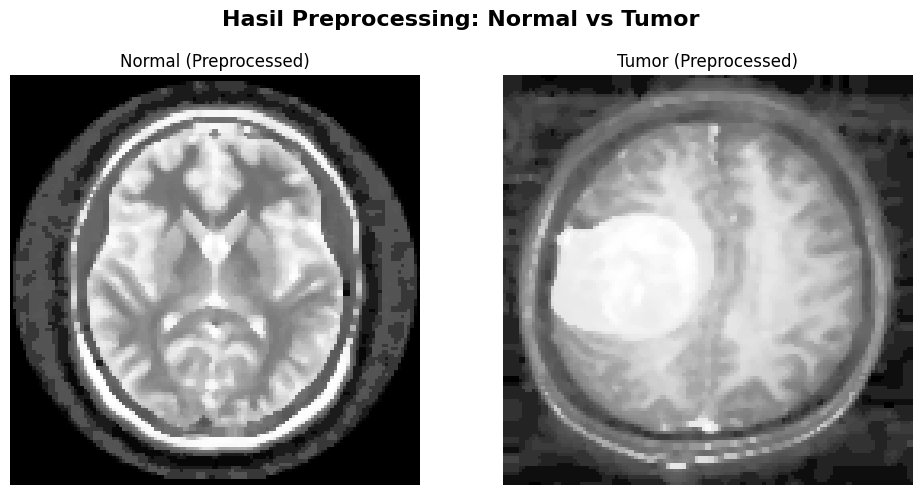

In [8]:
# ambil index berdasarkan label
normal_indx = [i for i, l in enumerate(labels) if l.lower() == "normal"]
tumor_indx = [i for i, l in enumerate(labels) if l.lower() == "tumor"]

# ambil hanya 1 sample dari masing-masing label
normal_indx = normal_indx[:1]
tumor_indx = tumor_indx[:1]

# gabungkan kedua label untuk ditampilkan bersama
all_idxs = normal_indx + tumor_indx
all_labels = ["Normal"] * len(normal_indx) + ["Tumor"] * len(tumor_indx)

def show_preprocessed_images(idxs, labels, title):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for i in range(len(idxs)):
        # Tampilkan hasil preprocessing (dataMedianEqual)
        axs[i].imshow(dataMedianEqual[idxs[i]], cmap='gray')
        axs[i].set_title(f"{labels[i]} (Preprocessed)", fontsize=12)
        axs[i].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# tampilkan hasil preprocessing
show_preprocessed_images(all_idxs, all_labels, "Hasil Preprocessing: Normal vs Tumor")

## Fungsi GLCM (Gray Level Co-occurrence Matrix)
Menghitung matriks GLCM dari sebuah gambar berdasarkan sudut tertentu (0°, 45°, 90°, 135°). GLCM digunakan untuk mengekstrak fitur tekstur citra.

In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

## Fungsi Ekstraksi Fitur Tekstur dari GLCM
Kumpulan fungsi untuk menghitung fitur-fitur tekstur dari matriks GLCM: contrast, correlation, energy, homogeneity, dissimilarity, ASM, dan entropy.

In [10]:
def correlation(matriks):
  	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Ekstraksi Fitur GLCM (Sudut 0°) untuk Semua Data
Menghitung fitur GLCM (sudut 0°) untuk seluruh gambar hasil preprocessing (`dataMedianEqual`), lalu menyimpannya dalam DataFrame dengan label tahap percobaan untuk keperluan dokumentasi/perbandingan.

In [11]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0

        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

def2 = ekstrak_fitur_glcm(dataMedianEqual, 'percobaan1')
display(def2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,640.682702,0.953122,0.239188,0.505810,11.704601,0.057211,5.520081,percobaan1
1,415.627522,0.970451,0.216643,0.415867,10.984683,0.046934,6.556259,percobaan1
2,782.538632,0.928597,0.660898,0.734993,8.766978,0.436786,3.152141,percobaan1
3,577.047367,0.956266,0.537734,0.655869,8.521777,0.289158,4.056808,percobaan1
4,631.665108,0.953807,0.410002,0.641878,9.532111,0.168102,4.463134,percobaan1
...,...,...,...,...,...,...,...,...
191,446.769993,0.964954,0.256342,0.547072,8.965859,0.065711,5.471959,percobaan1
192,1277.462721,0.912755,0.343697,0.531940,13.556102,0.118127,5.483495,percobaan1
193,410.044045,0.961539,0.055473,0.329024,10.584277,0.003077,7.367155,percobaan1
194,827.049090,0.942120,0.240093,0.443580,11.534941,0.057645,6.043937,percobaan1


## Hitung GLCM 4 Sudut untuk Semua Gambar
Menghitung matriks GLCM pada 4 sudut (0°, 45°, 90°, 135°) untuk setiap gambar hasil preprocessing, disimpan dalam list `Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`. Matriks ini akan dipakai untuk menghitung semua fitur tekstur.

In [12]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataMedianEqual)):
    D0 = glcm(dataMedianEqual[i], 0)
    D45 = glcm(dataMedianEqual[i], 45)
    D90 = glcm(dataMedianEqual[i], 90)
    D135 = glcm(dataMedianEqual[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)


## Inisialisasi List Penampung Fitur
Menyiapkan list kosong untuk menampung nilai fitur tekstur (contrast, dissimilarity, homogeneity, entropy, ASM, energy, correlation) pada masing-masing sudut.

In [13]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

## Hitung Correlation per Sudut
Menghitung nilai correlation dari setiap matriks GLCM (4 sudut) untuk semua gambar dan menyimpannya ke list yang sesuai.

In [14]:
for i in range(len(dataMedianEqual)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

## Hitung Contrast per Sudut
Menghitung nilai contrast dari setiap matriks GLCM (4 sudut) untuk semua gambar.

In [15]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

## Hitung Dissimilarity per Sudut
Menghitung nilai dissimilarity dari setiap matriks GLCM (4 sudut) untuk semua gambar.

In [16]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

## Hitung Homogeneity per Sudut
Menghitung nilai homogeneity dari setiap matriks GLCM (4 sudut) untuk semua gambar.

In [17]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

## Hitung Entropy per Sudut
Menghitung nilai entropy dari setiap matriks GLCM (4 sudut) untuk semua gambar.

In [18]:
for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

## Hitung ASM per Sudut
Menghitung nilai ASM (Angular Second Moment) dari setiap matriks GLCM (4 sudut) untuk semua gambar.

In [19]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

## Hitung Energy per Sudut
Menghitung nilai energy dari setiap matriks GLCM (4 sudut) untuk semua gambar.

In [20]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

## Gabungkan Semua Fitur ke DataFrame
Menggabungkan seluruh fitur tekstur (contrast, dissimilarity, homogeneity, entropy, ASM, energy, correlation) dari 4 sudut menjadi satu DataFrame `df_fitur` dengan 28 kolom fitur.

In [21]:
features = []

for i in range(len(dataMedianEqual)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

## Simpan & Tampilkan Tabel Hasil Ekstraksi
Menggabungkan nama file, label, dan seluruh fitur tekstur ke dalam satu tabel, menyimpannya sebagai CSV, lalu membacanya kembali untuk ditampilkan.

In [22]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1 no.jpeg,normal,640.682702,975.481183,580.056964,1014.288797,0.505810,0.447581,0.523254,0.447243,...,0.057593,0.051756,0.239188,0.227563,0.239985,0.227501,0.953122,0.928323,0.957556,0.925472
1,10 no.jpg,normal,415.627522,668.939240,327.672490,649.731229,0.415867,0.363815,0.421790,0.362411,...,0.048118,0.044070,0.216643,0.209205,0.219358,0.209928,0.970451,0.952318,0.976719,0.953687
2,11 no.jpg,normal,782.538632,941.492095,310.334892,935.130386,0.734993,0.713933,0.765680,0.714931,...,0.442412,0.432667,0.660898,0.657343,0.665140,0.657774,0.928597,0.914545,0.971685,0.915123
3,12 no.jpg,normal,577.047367,786.348193,377.342028,782.439457,0.655869,0.620599,0.675967,0.619527,...,0.293670,0.284570,0.537734,0.533772,0.541913,0.533451,0.956266,0.940636,0.971407,0.940931
4,13 no.jpg,normal,631.665108,714.181226,206.617557,751.951082,0.641878,0.612852,0.699013,0.613935,...,0.180877,0.167239,0.410002,0.408907,0.425297,0.408949,0.953807,0.947900,0.984933,0.945144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Y95.jpg,tumor,446.769993,644.140802,326.153789,668.717651,0.547072,0.470863,0.558820,0.472967,...,0.064967,0.058991,0.256342,0.243507,0.254886,0.242881,0.964954,0.949860,0.974416,0.947946
192,Y96.jpg,tumor,1277.462721,1997.996280,1131.978223,1902.889206,0.531940,0.476260,0.542926,0.476038,...,0.117848,0.111685,0.343697,0.334162,0.343290,0.334193,0.912755,0.863581,0.922691,0.870075
193,Y97.JPG,tumor,410.044045,742.301941,423.684117,799.359725,0.329024,0.248597,0.338038,0.240895,...,0.003094,0.002300,0.055473,0.048332,0.055627,0.047958,0.961539,0.930900,0.960753,0.925588
194,Y98.JPG,tumor,827.049090,1813.561907,1301.859498,1848.735569,0.443580,0.383826,0.481230,0.377954,...,0.057176,0.053101,0.240093,0.230402,0.239115,0.230438,0.942120,0.872118,0.908178,0.869643


## Analisis Korelasi & Seleksi Fitur
Menghitung korelasi antar fitur, lalu membuang fitur-fitur yang saling berkorelasi sangat tinggi (>= 0.95) untuk mengurangi redundansi. Sisa fitur (`x_new`) divisualisasikan dengan heatmap.

<Axes: >

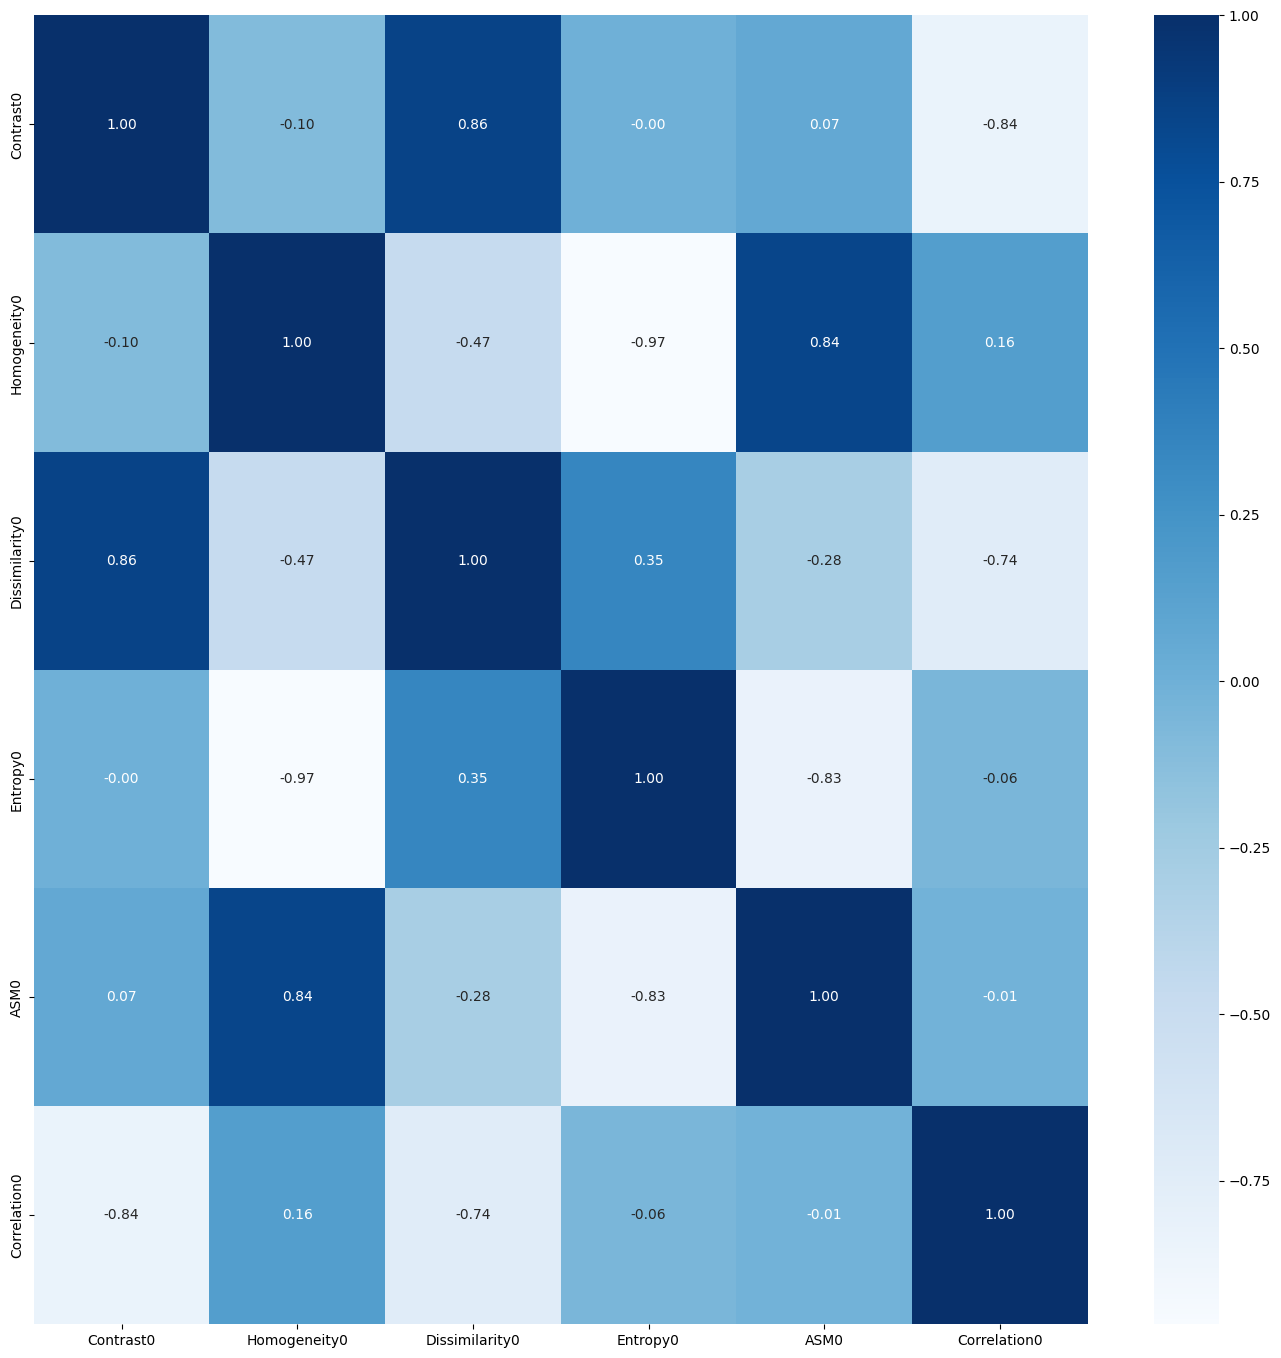

In [23]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Split Data Train-Test
Membagi data fitur (`x_new`) dan label (`y`) menjadi data latih (80%) dan data uji (20%) menggunakan `train_test_split`.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(147, 6)
(49, 6)
(147,)
(49,)


## Normalisasi Fitur (Standardization)
Melakukan normalisasi Z-score (mean=0, std=1) pada data fitur. Statistik mean dan std dihitung dari data latih, kemudian diterapkan ke data latih dan uji agar tidak ada data leakage.

In [25]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Definisi Model & Fungsi Evaluasi
Membuat fungsi `generateClassificationReport` untuk menampilkan classification report, confusion matrix, dan akurasi. Mendefinisikan tiga model klasifikasi: Random Forest, SVM, dan KNN.

In [26]:
def generateClassificationReport(y_true, y_pred):
  print(classification_report(y_true, y_pred))
  print(confusion_matrix(y_true, y_pred))
  print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Training & Evaluasi Random Forest
Melatih model Random Forest dengan data latih, lalu mengevaluasi performanya pada data latih dan data uji.

In [27]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      normal       0.97      0.97      0.97        72
       tumor       0.97      0.97      0.97        75

    accuracy                           0.97       147
   macro avg       0.97      0.97      0.97       147
weighted avg       0.97      0.97      0.97       147

[[70  2]
 [ 2 73]]
Accuracy: 0.9727891156462585

------Testing Set------
              precision    recall  f1-score   support

      normal       0.81      0.81      0.81        26
       tumor       0.78      0.78      0.78        23

    accuracy                           0.80        49
   macro avg       0.80      0.80      0.80        49
weighted avg       0.80      0.80      0.80        49

[[21  5]
 [ 5 18]]
Accuracy: 0.7959183673469388


## Training & Evaluasi SVM
Melatih model SVM (kernel RBF) dengan data latih, lalu mengevaluasi performanya pada data latih dan data uji.

In [28]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.78      0.69      0.74        72
       tumor       0.73      0.81      0.77        75

    accuracy                           0.76       147
   macro avg       0.76      0.75      0.75       147
weighted avg       0.76      0.76      0.75       147

[[50 22]
 [14 61]]
Accuracy: 0.7551020408163265

------Testing Set------
              precision    recall  f1-score   support

      normal       0.73      0.62      0.67        26
       tumor       0.63      0.74      0.68        23

    accuracy                           0.67        49
   macro avg       0.68      0.68      0.67        49
weighted avg       0.68      0.67      0.67        49

[[16 10]
 [ 6 17]]
Accuracy: 0.673469387755102


## Training & Evaluasi KNN
Melatih model KNN (k=5) dengan data latih, lalu mengevaluasi performanya pada data latih dan data uji.

In [29]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.79      0.78      0.78        72
       tumor       0.79      0.80      0.79        75

    accuracy                           0.79       147
   macro avg       0.79      0.79      0.79       147
weighted avg       0.79      0.79      0.79       147

[[56 16]
 [15 60]]
Accuracy: 0.7891156462585034

------Testing Set------
              precision    recall  f1-score   support

      normal       0.74      0.54      0.62        26
       tumor       0.60      0.78      0.68        23

    accuracy                           0.65        49
   macro avg       0.67      0.66      0.65        49
weighted avg       0.67      0.65      0.65        49

[[14 12]
 [ 5 18]]
Accuracy: 0.6530612244897959


## Visualisasi Confusion Matrix
Menampilkan confusion matrix untuk masing-masing model (Random Forest, SVM, KNN) pada data uji secara visual.

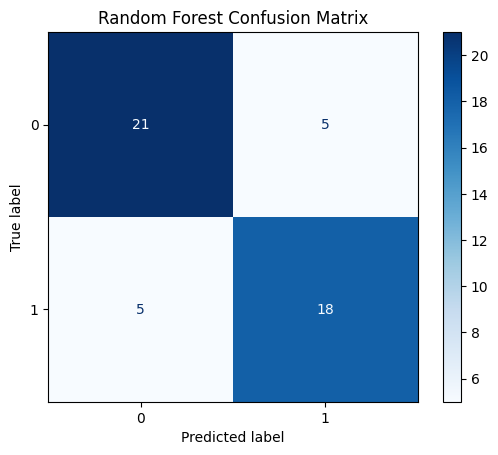

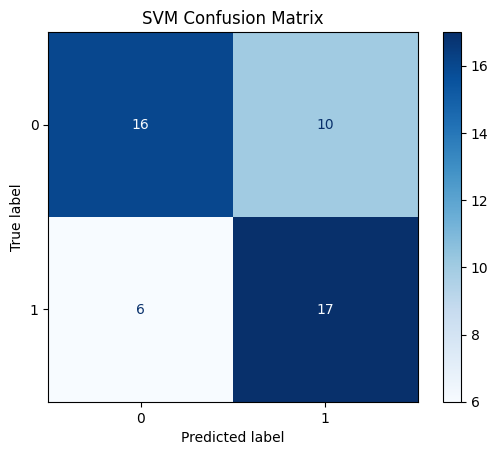

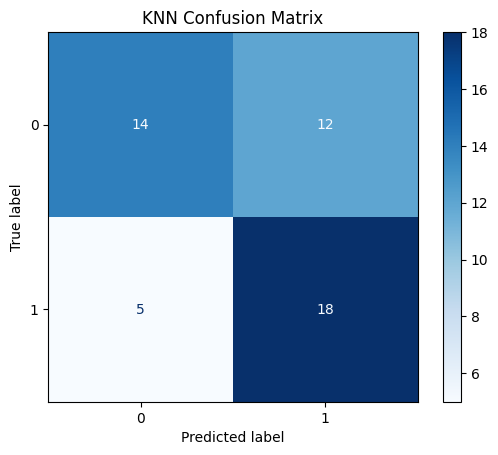

In [30]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Evaluasi Percobaan 2: Median Filter + Sharpening

Pada percobaan ini, preprocessing tambahan berupa median filter (3x3) diterapkan untuk 
mengurangi noise pada citra, diikuti dengan sharpening menggunakan kernel konvolusi untuk 
mempertegas tepi/detail sebelum dilakukan ekstraksi fitur GLCM.

**Hasil Akurasi:**
- Random Forest : 0.9591836734693877(training) / 0.7346938775510204 (testing)
- SVM           : 0.7619047619047619 (training) / 0.7551020408163265 (testing)
- KNN           : 0.8367346938775511 (training) / 0.673469387755102 (testing)

**Perbandingan dengan Baseline (tanpa median+sharpening):**
[Isi setelah punya angka percobaan 1 - lihat catatan di bawah]

**Analisis:**
Analisis:

- Random Forest menunjukkan performa terbaik pada data training (0.959) namun mengalami penurunan cukup signifikan pada data testing (0.735). Gap sebesar 0.224 ini mengindikasikan overfitting, dimana model terlalu kompleks dan menghafal pola pada data latih sehingga kurang mampu menggeneralisasi ke data baru. Meskipun demikian, akurasi testing 0.735 masih tergolong cukup baik untuk klasifikasi citra medis.

- SVM dengan kernel RBF menunjukkan performa paling stabil dengan gap training-testing terkecil (0.007), dimana akurasi training 0.762 dan testing 0.755. Model ini tidak mengalami overfitting maupun underfitting yang signifikan, menjadikannya model paling konsisten dan dapat diandalkan di antara ketiga model. Akurasi testing 0.755 menunjukkan SVM mampu membedakan kedua kelas dengan cukup baik.

- KNN dengan k=5 menunjukkan gap sedang antara training (0.837) dan testing (0.673) sebesar 0.164, mengindikasikan overfitting ringan. Performa testing KNN (0.673) merupakan yang terendah di antara ketiga model, menunjukkan bahwa pendekatan berbasis jarak (distance-based) kurang efektif untuk data ini dibandingkan model berbasis pohon (RF) atau hyperplane (SVM).

Kesimpulan:

Berdasarkan hasil di atas, model SVM merupakan pilihan terbaik dengan akurasi testing tertinggi (0.755) dan stabilitas antar split data yang sangat baik. Random Forest menunjukkan potensi tinggi namun memerlukan regularisasi (pengaturan hyperparameter seperti max_depth dan min_samples_split) untuk mengurangi overfitting. KNN kurang direkomendasikan untuk kasus ini karena akurasi testing terendah. Secara keseluruhan, preprocessing median filter + histogram equalization memberikan hasil yang cukup baik, terutama pada model SVM, namun masih terdapat ruang untuk peningkatan melalui optimasi hyperparameter dan eksplorasi preprocessing lain seperti CLAHE atau sharpening yang lebih agresif.

In [31]:
# ==========================
# TABEL PERBANDINGAN MODEL
# ==========================

hasil = []

models = {
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn
}

for nama, model in models.items():
    y_pred = model.predict(X_test)

    hasil.append([
        nama,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

df_hasil = pd.DataFrame(
    hasil,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("TABEL PERBANDINGAN MODEL")
display(df_hasil.round(6))



TABEL PERBANDINGAN MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.795918,0.795918,0.795918,0.795918
1,SVM,0.673469,0.681440,0.673469,0.672925
2,KNN,0.653061,0.672610,0.653061,0.648988
